In [1]:
import torch
import torch.nn as nn
from torchvision import utils
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from utils import extract, linear_beta_schedule, UNet_cond

In [2]:
# Load custom MNIST dataset
data = torch.load("mnist_custom.pt", weights_only=False)

train_images = data["train_images"]
train_labels = data["train_labels"]
test_images = data["test_images"]
test_labels = data["test_labels"]

# Normalize to [-1, 1]
train_images = train_images * 2 - 1
test_images = test_images * 2 - 1

## Training Loss Convergence

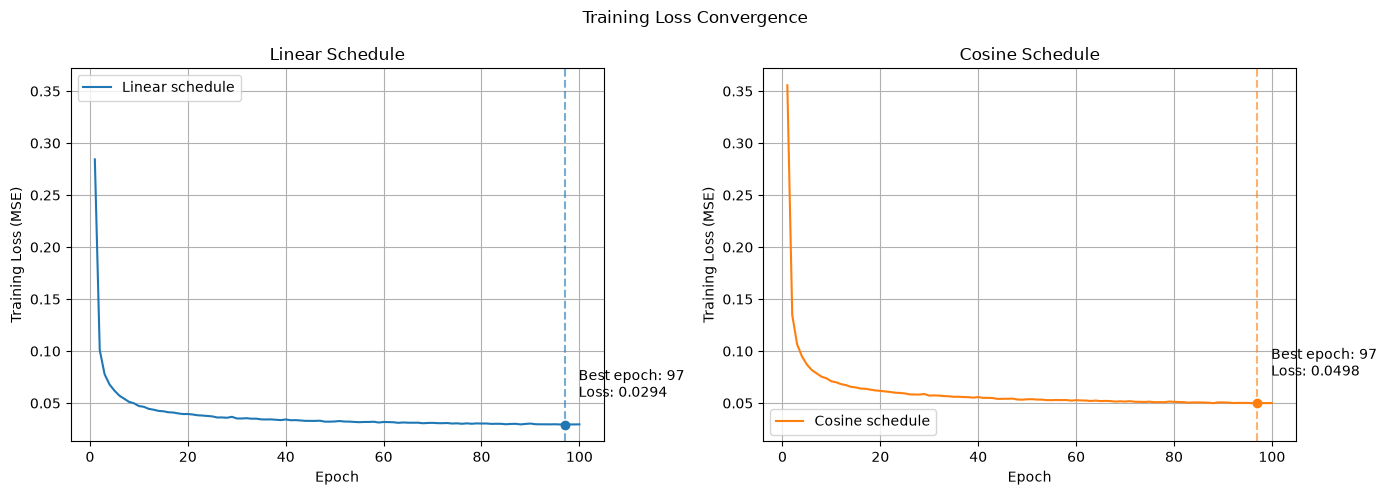

In [3]:
linear_loss = np.load("models/linear_loss.npy")
cosine_loss = np.load("models/cosine_loss.npy")

epochs = np.arange(1, len(linear_loss) + 1)

linear_best_epoch = np.argmin(linear_loss) + 1
linear_best_loss = np.min(linear_loss)

cosine_best_epoch = np.argmin(cosine_loss) + 1
cosine_best_loss = np.min(cosine_loss)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Linear schedule
axes[0].plot(epochs, linear_loss, label="Linear schedule", color="tab:blue")
axes[0].axvline(linear_best_epoch, linestyle="--", alpha=0.6, color="tab:blue")
axes[0].scatter(linear_best_epoch, linear_best_loss, color="tab:blue", zorder=5)
axes[0].annotate(
    f"Best epoch: {linear_best_epoch}\nLoss: {linear_best_loss:.4f}",
    (linear_best_epoch, linear_best_loss),
    xytext=(10, 20),
    textcoords="offset points"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss (MSE)")
axes[0].set_title("Linear Schedule")
axes[0].grid(True)
axes[0].legend()

# Cosine schedule
axes[1].plot(epochs, cosine_loss, label="Cosine schedule", color="tab:orange")
axes[1].axvline(cosine_best_epoch, linestyle="--", alpha=0.6, color="tab:orange")
axes[1].scatter(cosine_best_epoch, cosine_best_loss, color="tab:orange", zorder=5)
axes[1].annotate(
    f"Best epoch: {cosine_best_epoch}\nLoss: {cosine_best_loss:.4f}",
    (cosine_best_epoch, cosine_best_loss),
    xytext=(10, 20),
    textcoords="offset points"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Training Loss (MSE)")
axes[1].set_title("Cosine Schedule")
axes[1].tick_params(axis="y", labelleft=True)
axes[1].grid(True)
axes[1].legend()

fig.suptitle("Training Loss Convergence")
plt.tight_layout()
plt.savefig("plots/training_loss_convergence.png", dpi=300, bbox_inches="tight")
plt.show()

## Comparison of the models (inference) / 120 images per model

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

timesteps = 1000
image_size = 20
channels = 1

@torch.no_grad()
def p_sample_cDDPM(model, x_t, t_index, y):
    t = torch.full((x_t.shape[0],), t_index, device=x_t.device, dtype=torch.long)

    beta = extract(betas, t, x_t.shape)
    alpha = extract(alphas, t, x_t.shape)
    alpha_bar = extract(alpha_bars, t, x_t.shape)
    sigma = torch.sqrt(beta)

    pred_noise = model(x_t, t, y)

    if t_index == 0:
        z = 0
    else:
        z = torch.randn_like(x_t)

    x_tm1 = 1.0 / alpha.sqrt() * (x_t - beta / ((1 - alpha_bar).sqrt()) * pred_noise) + sigma * z

    return x_tm1

@torch.no_grad()
def p_sample_loop_cDDPM(model, y, initial_noise, seed=42):
    model.eval()
    torch.manual_seed(seed)

    x = initial_noise.clone().to(device)

    timesteps_investigated = [500, 250, 100, 50, 25, 0]
    progress = {}

    pbar = tqdm(reversed(range(0, timesteps)), desc="Sampling loop", total=timesteps)

    for t in pbar:
        x = p_sample_cDDPM(model, x, t, y)

        if t in timesteps_investigated:
            progress[t] = x.clamp(-1, 1).detach().cpu()

    return x.clamp(-1, 1), progress

def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)

    alpha_bars = torch.cos(((x / timesteps + s) / (1 + s)) * torch.pi * 0.5) ** 2

    alpha_bars = alpha_bars / alpha_bars[0]
    betas = 1 - (alpha_bars[1:] / alpha_bars[:-1])

    return torch.clip(betas, 0.0001, 0.9999)

In [5]:
# 12 samples for each digit (0-9)
sample_per_class = 12
labels = torch.arange(0, 10).unsqueeze(1).repeat(1, sample_per_class).view(-1).to(device)

# Same initial noise for both models
torch.manual_seed(42)
initial_noise = torch.randn(labels.shape[0], channels, image_size, image_size).to(device)

In [6]:
# Linear schedule
betas = linear_beta_schedule(timesteps).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

linear_model = UNet_cond(ch=32, n_classes=10).to(device)
linear_model.load_state_dict(torch.load("models/linear_best_model.pth", map_location=device))
linear_model.eval()

# Final samples + intermediate denoising samples
linear_samples, linear_progress = p_sample_loop_cDDPM(linear_model, labels, initial_noise, seed=42)
linear_samples = (linear_samples + 1.0) / 2.0

# Cosine schedule
betas = cosine_beta_schedule(timesteps).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

cosine_model = UNet_cond(ch=32, n_classes=10).to(device)
cosine_model.load_state_dict(torch.load("models/cosine_best_model.pth", map_location=device))
cosine_model.eval()

# Final samples + intermediate denoising samples
cosine_samples, cosine_progress = p_sample_loop_cDDPM(cosine_model, labels, initial_noise, seed=42)
cosine_samples = (cosine_samples + 1.0) / 2.0

Sampling loop: 100%|██████████| 1000/1000 [00:04<00:00, 218.84it/s]


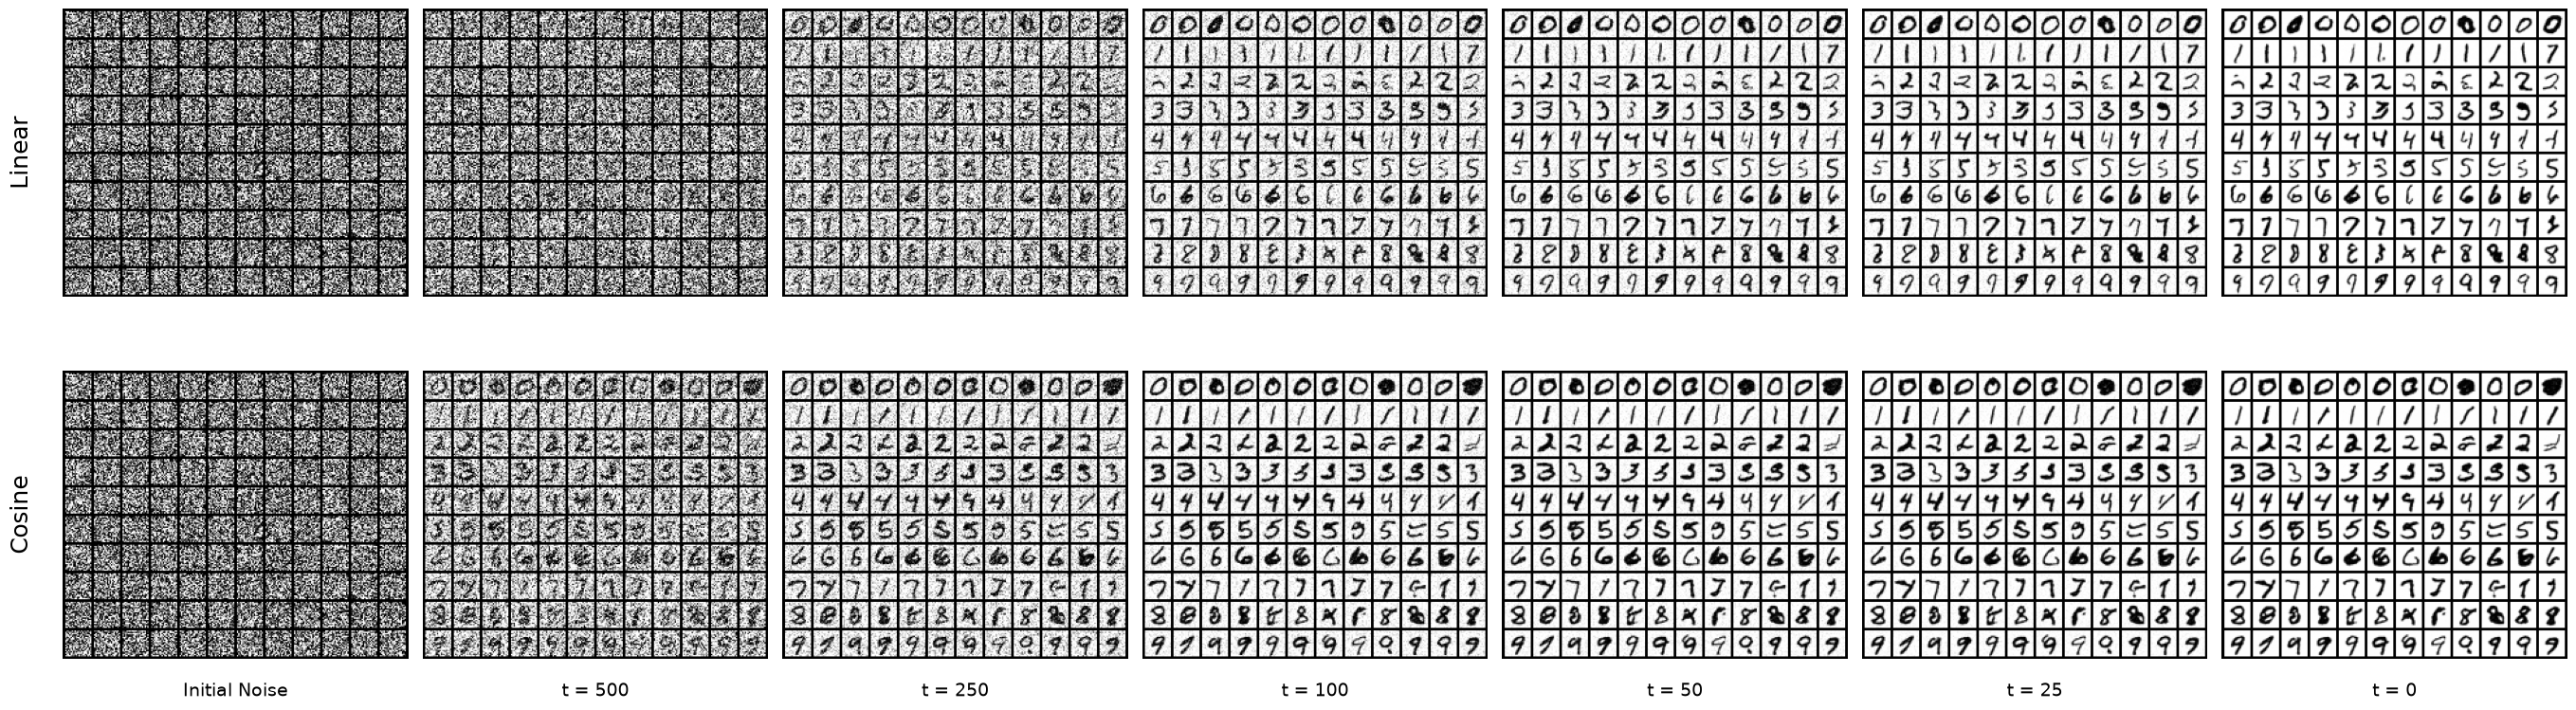

In [7]:
# Timesteps to investigate during the reverse denoising process
timesteps_investigated = [500, 250, 100, 50, 25, 0]

# Create 2 rows: Linear (top) and Cosine (bottom) / Columns: Initial Noise + investigated timesteps
fig, axes = plt.subplots(2, len(timesteps_investigated) + 1, figsize=(28, 10))

# Initial noise - same for Linear and Cosine
initial_grid = utils.make_grid((initial_noise.cpu().clamp(-1, 1) + 1) / 2, nrow=12)
axes[0, 0].imshow(initial_grid.permute(1, 2, 0))
axes[0, 0].axis("off")
axes[1, 0].imshow(initial_grid.permute(1, 2, 0))
axes[1, 0].axis("off")

# Denoising progress for each investigated timestep
for i, t in enumerate(timesteps_investigated, start=1):
    # Linear and Cosine samples at timestep t
    linear_grid = utils.make_grid((linear_progress[t] + 1) / 2, nrow=12)
    cosine_grid = utils.make_grid((cosine_progress[t] + 1) / 2, nrow=12)
    # Linear schedule - top row
    axes[0, i].imshow(linear_grid.permute(1, 2, 0))
    axes[0, i].axis("off")
    # Cosine schedule - bottom row
    axes[1, i].imshow(cosine_grid.permute(1, 2, 0))
    axes[1, i].axis("off")

# Column labels - display below the plots
column_labels = ["Initial Noise"] + [f"t = {t}" for t in timesteps_investigated]
for i, label in enumerate(column_labels):
    axes[1, i].text(0.5, -0.08, label, transform=axes[1, i].transAxes, ha="center", va="top", fontsize=14)

# Row labels - display on the left
axes[0, 0].annotate("Linear", xy=(-0.12, 0.5), xycoords="axes fraction", ha="center", va="center", rotation=90, fontsize=18)
axes[1, 0].annotate("Cosine", xy=(-0.12, 0.5), xycoords="axes fraction", ha="center", va="center", rotation=90, fontsize=18)

# Save and display figure
plt.tight_layout(rect=[0.03, 0.04, 1, 0.96], h_pad=0.2)
plt.savefig("plots/denoising_progress_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

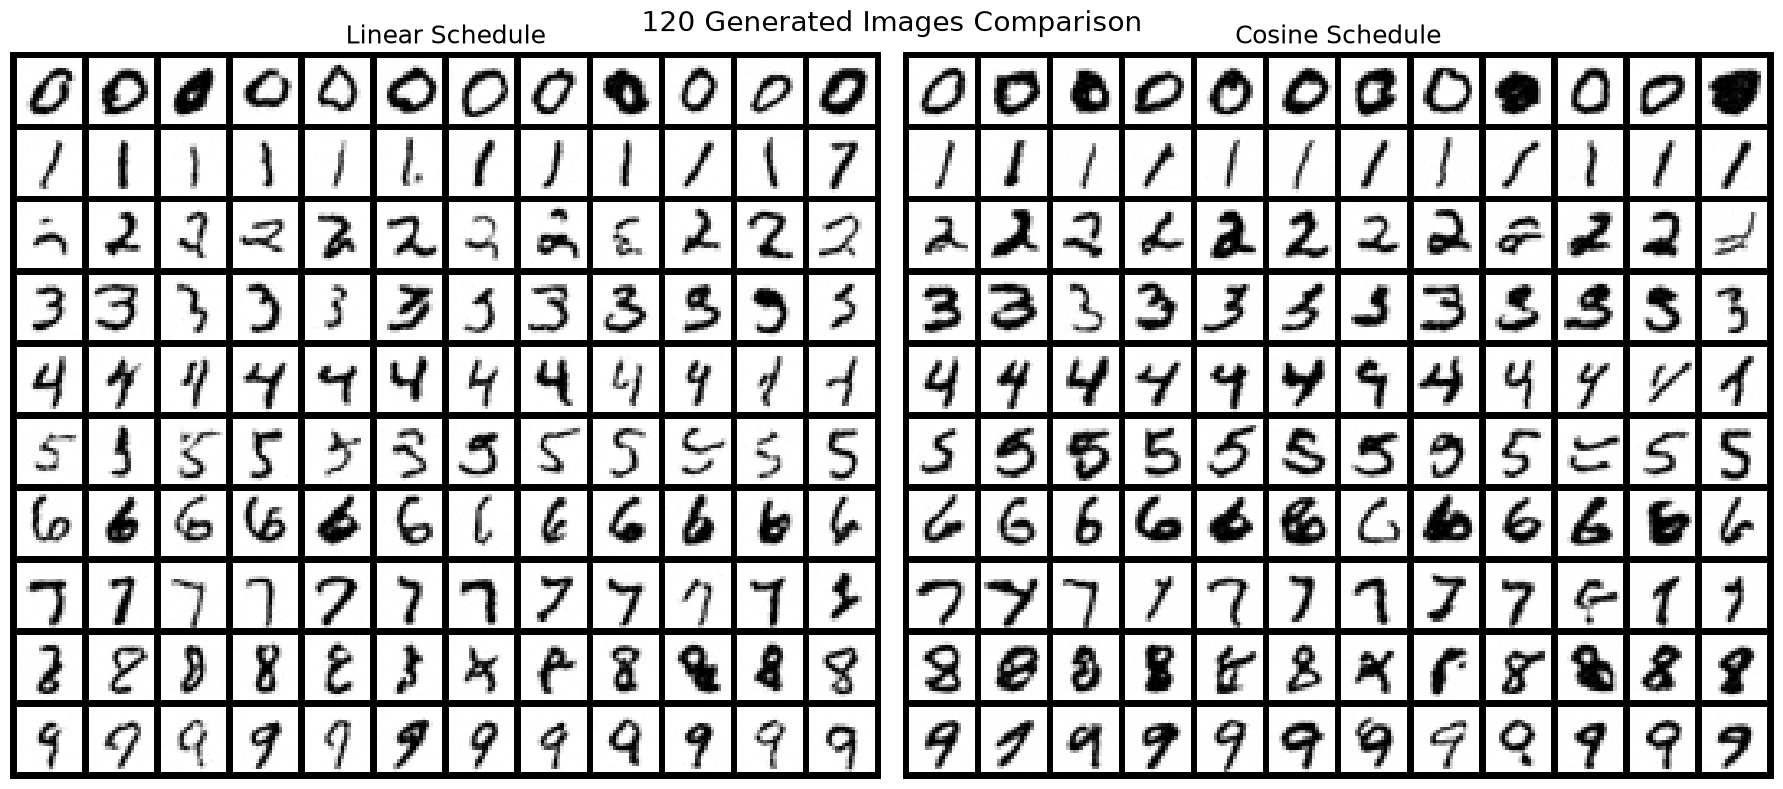

In [8]:
# Compare final generated images from Linear and Cosine schedules
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Create a 12 × 10 grid for each model
linear_grid = utils.make_grid(linear_samples.cpu(), nrow=12, padding=2, pad_value=0)
cosine_grid = utils.make_grid(cosine_samples.cpu(), nrow=12, padding=2, pad_value=0)

# Linear schedule
axes[0].imshow(linear_grid.permute(1, 2, 0))
axes[0].set_title("Linear Schedule", fontsize=18)
axes[0].axis("off")

# Cosine schedule
axes[1].imshow(cosine_grid.permute(1, 2, 0))
axes[1].set_title("Cosine Schedule", fontsize=18)
axes[1].axis("off")

# Figure title
fig.suptitle("120 Generated Images Comparison", fontsize=20)

# Layout
plt.tight_layout()

# Save and display figure
plt.savefig("plots/generated_images_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

The cosine schedule produced recognizable digit structures earlier in the reverse denoising process than the linear schedule.  
This may be because the cosine schedule adds noise more gradually during the forward diffusion process, allowing useful image information to be preserved for longer.  

However, the final generated samples did not show a clear improvement in image quality.   
This suggests that the main benefit observed in this experiment was earlier recovery of recognizable structures rather than an improvement in the final generation quality.  